In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [2]:
df = pd.read_csv('C:\\Users\\rkhadka1\\OneDrive - Lamar University\\Research\\Roshanbeam3\\Nonlinear restoring force\\Nonlinearforce_Data\\Non_linear_force_4m_045g.csv')

In [3]:
df = df.rename(columns={'Modal_Displacement': 'q'})
df = df.rename(columns={'Non_linear_Force': 'Fnl'})
df = df.rename(columns={'Modal_Velocity': 'qdot'})
display(df)

,Fnl,q,qdot
0,0.917871,0.000131,-0.090407
1,0.902382,0.000126,-0.090700
2,0.886264,0.000122,-0.090985
3,0.869535,0.000117,-0.091262
4,0.852211,0.000113,-0.091530
...,...,...,...
81917,943.554706,-0.000492,0.127907
81918,931.439776,-0.000486,0.128677
81919,919.504266,-0.000480,0.129421
81920,907.251782,-0.000473,0.130172


In [4]:
import numpy as np


# Suppose your current df has columns: ['q', 'Fnl'] and length = 2N
N = len(df) // 2

q1   = df.loc[:N-1, 'q'].to_numpy()
qdot1 = df.loc[:N-1, 'qdot'].to_numpy()
Fnl1 = df.loc[:N-1, 'Fnl'].to_numpy()



q2   = df.loc[N:2*N-1, 'q'].to_numpy()
qdot2 = df.loc[N:2*N-1, 'qdot'].to_numpy()
Fnl2 = df.loc[N:2*N-1, 'Fnl'].to_numpy()

df_wide = pd.DataFrame({
    'q1': q1,
    'qdot1': qdot1,
    'q2': q2,
    'qdot2': qdot2,
    'Fnl1': Fnl1,
    'Fnl2': Fnl2
})


In [5]:
from sklearn.linear_model import Lasso

In [6]:
N = len(df) // 2

q1   = df.loc[:N-1, 'q'].to_numpy()
qdot1 = df.loc[:N-1, 'qdot'].to_numpy()
Fnl1 = df.loc[:N-1, 'Fnl'].to_numpy()



q2   = df.loc[N:2*N-1, 'q'].to_numpy()
qdot2 = df.loc[N:2*N-1, 'qdot'].to_numpy()
Fnl2 = df.loc[N:2*N-1, 'Fnl'].to_numpy()

df_wide = pd.DataFrame({
    'q1': q1,
    'qdot1': qdot1,
    'q2': q2,
    'qdot2': qdot2,
    'Fnl1': Fnl1,
    'Fnl2': Fnl2
})

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# Extract variables
q1 = df_wide['q1'].values
qdot1 = df_wide['qdot1'].values
q2 = df_wide['q2'].values
qdot2 = df_wide['qdot2'].values

Fnl1 = df_wide['Fnl1'].values
Fnl2 = df_wide['Fnl2'].values

# -----------------------------
# Candidate Library Θ(X)
# -----------------------------
Theta = pd.DataFrame({
    '1': np.ones_like(q1),

    # Linear terms
    'q1': q1,
    'q2': q2,
    'qdot1': qdot1,
    'qdot2': qdot2,

    # Quadratic
    'q1^2': q1**2,
    'q2^2': q2**2,
    'q1*q2': q1*q2,
    'qdot1^2': qdot1**2,
    'qdot2^2': qdot2**2,
    'q1*qdot1': q1*qdot1,
    'q2*qdot2': q2*qdot2,

    # Cubic
    'q1^3': q1**3,
    'q2^3': q2**3,
    'q1^2*q2': (q1**2)*q2,
    'q1*q2^2': q1*(q2**2),

    # Velocity nonlinear
    'qdot1^3': qdot1**3,
    'qdot2^3': qdot2**3
})

In [8]:
scaler = StandardScaler()
Theta_scaled = scaler.fit_transform(Theta)

In [9]:
lasso1 = Lasso(alpha=1e-4, max_iter=10000)
lasso1.fit(Theta_scaled, Fnl1)

coef_scaled1 = lasso1.coef_
coef1 = coef_scaled1 / scaler.scale_
intercept1 = lasso1.intercept_ - np.sum(coef_scaled1 * scaler.mean_ / scaler.scale_)

print("\n Mode 1 Equation:\n")
for c, name in zip(coef1, Theta.columns):
    if abs(c) > 1e-5:
        print(f"{c:+.4e} * {name}")
print(f"{intercept1:+.4e} (bias)")


 Mode 1 Equation:

+3.4569e+03 * q1
+7.7370e+01 * q2
+7.5428e+00 * qdot1
-1.4903e+06 * q1^2
-2.6266e+06 * q2^2
-3.6564e+01 * qdot1^2
+4.0233e+01 * qdot2^2
-1.8315e+02 * q2*qdot2
-1.4995e+10 * q1^3
-3.1034e+09 * q2^3
+3.1011e+02 * qdot1^3
+7.6764e-01 (bias)


In [10]:
equation1_str = "Fnl1 = "
for c, name in zip(coef1, Theta.columns):
    if abs(c) > 1e-5:
        equation1_str += f"{c:+.4e} * {name} + "
equation1_str += f"{intercept1:+.4e}"

print(equation1_str)


Fnl1 = +3.4569e+03 * q1 + +7.7370e+01 * q2 + +7.5428e+00 * qdot1 + -1.4903e+06 * q1^2 + -2.6266e+06 * q2^2 + -3.6564e+01 * qdot1^2 + +4.0233e+01 * qdot2^2 + -1.8315e+02 * q2*qdot2 + -1.4995e+10 * q1^3 + -3.1034e+09 * q2^3 + +3.1011e+02 * qdot1^3 + +7.6764e-01


In [11]:
print("\n Mode 1 Equation - Ranked Coefficients:\n")

# Create a list of (absolute_coefficient, coefficient, feature_name) tuples
ranked_coefficients = []
for c, name in zip(coef1, Theta.columns):
    if abs(c) > 1e-5: # Filter out very small coefficients
        ranked_coefficients.append((abs(c), c, name))

# Sort by absolute coefficient in descending order
ranked_coefficients.sort(key=lambda x: x[0], reverse=True)

# Print the ranked coefficients
for abs_c, c, name in ranked_coefficients:
    print(f"{c:+.4e} * {name}")
print(f"{intercept1:+.4e} (bias)")


 Mode 1 Equation - Ranked Coefficients:

-1.4995e+10 * q1^3
-3.1034e+09 * q2^3
-2.6266e+06 * q2^2
-1.4903e+06 * q1^2
+3.4569e+03 * q1
+3.1011e+02 * qdot1^3
-1.8315e+02 * q2*qdot2
+7.7370e+01 * q2
+4.0233e+01 * qdot2^2
-3.6564e+01 * qdot1^2
+7.5428e+00 * qdot1
+7.6764e-01 (bias)


In [12]:
from sklearn.metrics import r2_score

# Mode 1
y_pred1 = Theta.values @ coef1 + intercept1
print("\nMode 1 R²:", r2_score(Fnl1, y_pred1))



Mode 1 R²: 0.9999888932620747


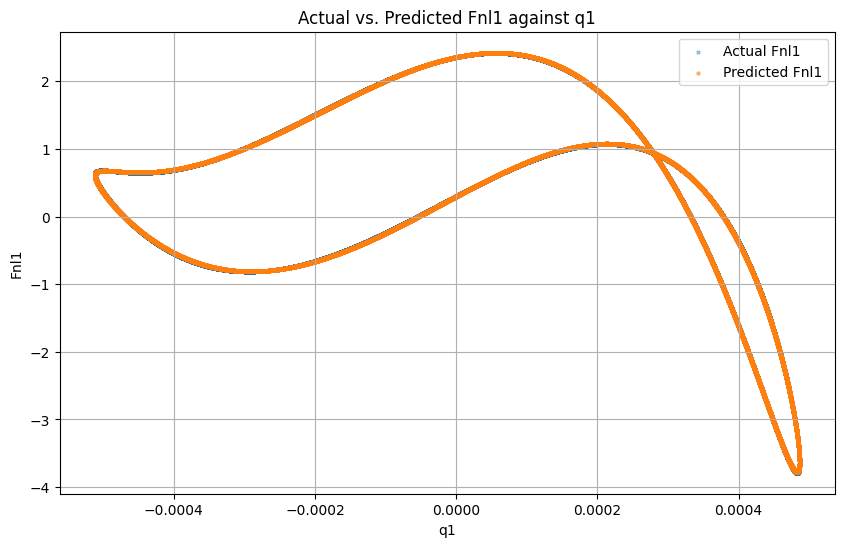

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(q1, Fnl1, alpha=0.5, label='Actual Fnl1', marker='x', s=5)
plt.scatter(q1, y_pred1, alpha=0.5, label='Predicted Fnl1', marker='o', s=5)
plt.xlabel('q1')
plt.ylabel('Fnl1')
plt.title('Actual vs. Predicted Fnl1 against q1')
plt.grid(True)
plt.legend()
plt.show()

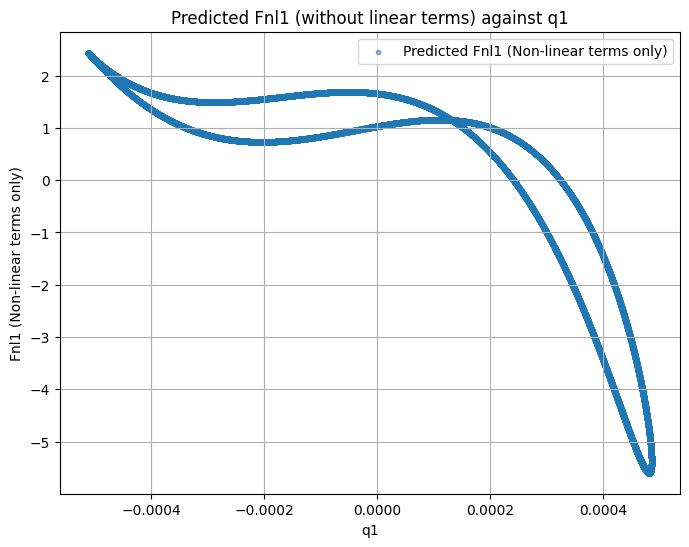

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Create a copy of the coefficients for Fnl1
coef1_nonlinear = np.copy(coef1)

# Get the indices of linear terms in Theta.columns
linear_terms_indices = [
    Theta.columns.get_loc('q1'),
    Theta.columns.get_loc('q2'),
    Theta.columns.get_loc('qdot1'),
    Theta.columns.get_loc('qdot2')
]

# Set the coefficients of linear terms to zero
for idx in linear_terms_indices:
    coef1_nonlinear[idx] = 0.0

# Recalculate y_pred1 without linear terms
y_pred1_nonlinear = Theta.values @ coef1_nonlinear + intercept1

plt.figure(figsize=(8, 6))
plt.scatter(q1, y_pred1_nonlinear, alpha=0.5, label='Predicted Fnl1 (Non-linear terms only)', s=10)
plt.xlabel('q1')
plt.ylabel('Fnl1 (Non-linear terms only)')
plt.title('Predicted Fnl1 (without linear terms) against q1')
plt.grid(True)
plt.legend()
plt.show()

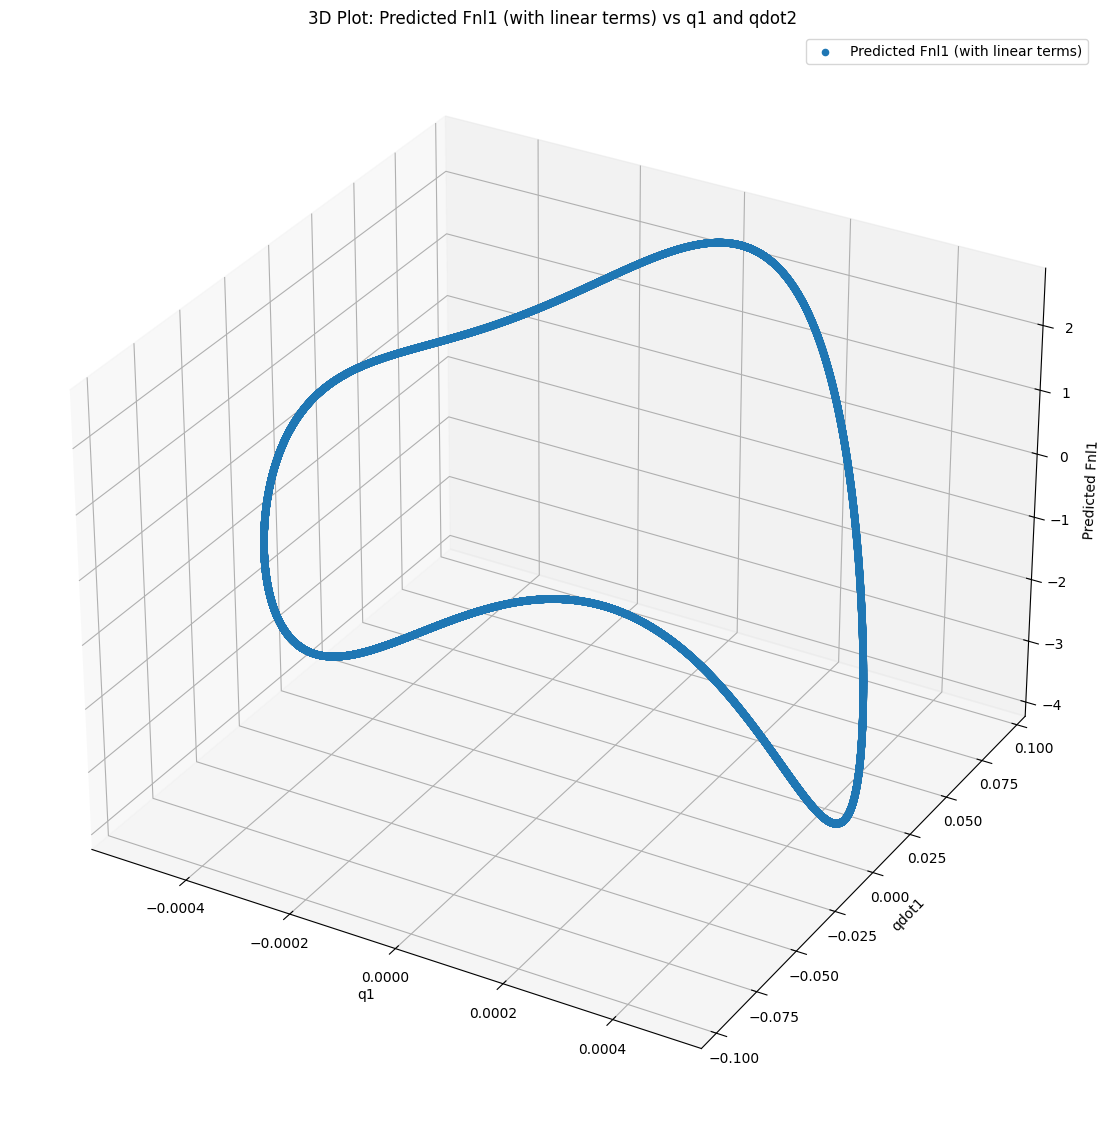

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(14, 15))
ax = fig.add_subplot(111, projection='3d')

# Plot Fnl1 with linear terms
ax.scatter(q1, qdot1,y_pred1, label='Predicted Fnl1 (with linear terms)')

ax.set_xlabel('q1')
ax.set_ylabel('qdot1')
ax.set_zlabel(' Predicted Fnl1 ')
ax.set_title('3D Plot: Predicted Fnl1 (with linear terms) vs q1 and qdot2')
ax.legend()
plt.show()